In [14]:
from pyarrow.dataset import dataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

mnist = fetch_openml('mnist_784', version=1, as_frame=False) # X: (70000, 784)
X, y = mnist["data"], mnist["target"]
X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)
# scale to [0, 1]
X_trainval, X_test, y_trainval, y_test = train_test_split(
X, y, test_size=10000, random_state=42, stratify=y
)


## MLP Model

In [16]:
import os
import torch
from torch import nn

class MLP_Model(nn.Module):
    def __init__(self):
        super(MLP_Model, self).__init__()
        self.input = nn.Linear(784,2 * 784 )
        self.hidden = nn.Linear(2*784, 2*784)
        self.output = nn.Linear(2*784, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input(x))
        x = self.relu(self.hidden(x))
        x = self.output(x)

        return x


os.makedirs('Models', exist_ok=True)

# Training Loop

---FOLD 0 ---


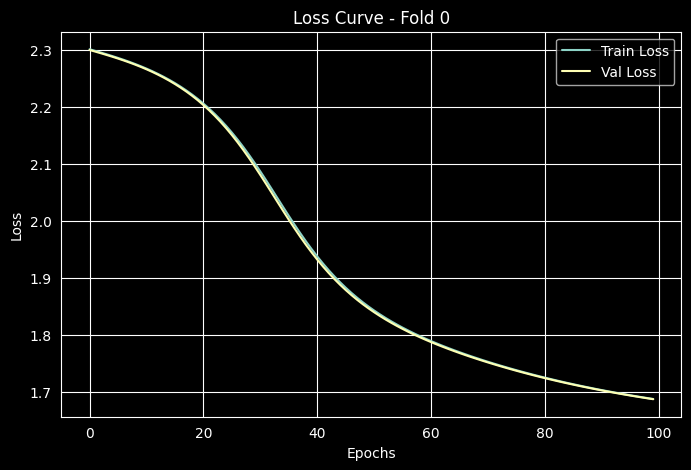

---FOLD 1 ---


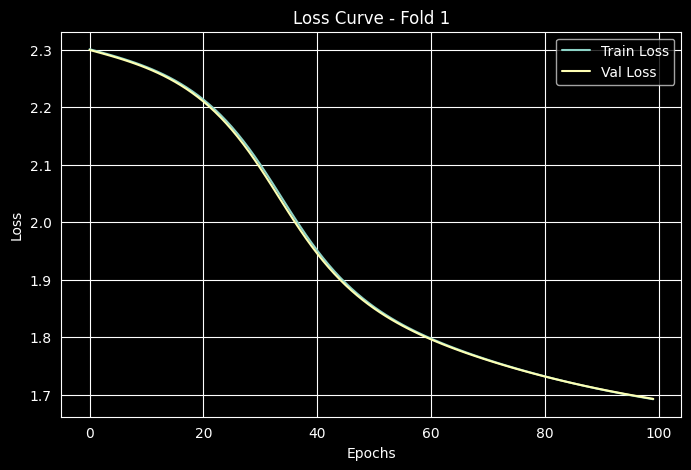

---FOLD 2 ---


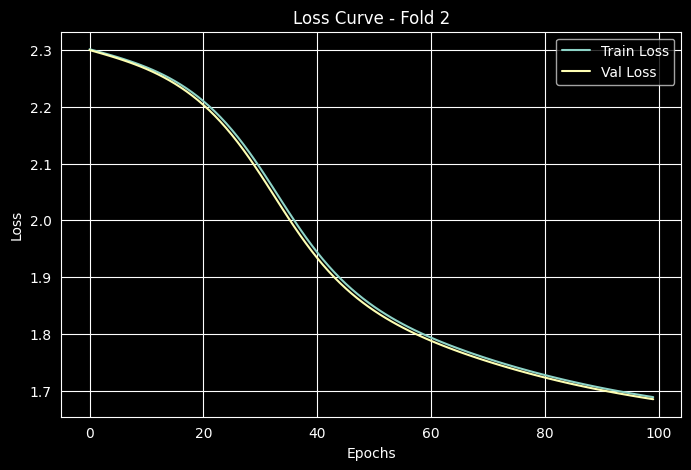

---FOLD 3 ---


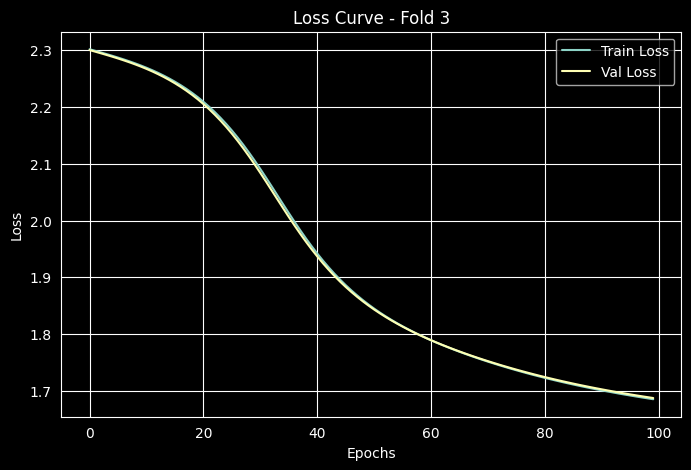

---FOLD 4 ---


KeyboardInterrupt: 

In [13]:
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, Subset
from torch import optim

# Data
X_trainval_tensor = torch.from_numpy(X_trainval).float()
y_trainval_tensor = torch.from_numpy(y_trainval).long()
dataset = TensorDataset(X_trainval_tensor, y_trainval_tensor)

# HYPERPARAMETERS and settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 100
batch_size = 1024
lr = 0.01
folds = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(folds.split(X_trainval)):
    print(f"---FOLD {fold} ---")

    # Fold Split and Loaders
    train_sample = Subset(dataset, train_index)
    val_sample = Subset(dataset, val_index)

    train_loader = DataLoader(train_sample, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_sample, batch_size=batch_size, shuffle=False)

    #Model, Optimizer and Loss
    model = MLP_Model().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    history = {'train_loss':[], 'val_loss':[]}

    # Training Loop
    model.train()

    for epoch in range(num_epochs):
        train_running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            train_running_loss += loss.item()

        avg_train_loss = train_running_loss / len(train_loader)

        # Model Validation
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for x,y in val_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)
                loss = criterion(output, y)
                val_running_loss += loss.item()

        avg_val_loss = val_running_loss / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        # Saving Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            checkpoint = {
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
                'history': history
            }
            PATH = os.path.join('Models', f'model_{fold}.pth')
            torch.save(checkpoint, PATH)
            #print(f"Epoch {epoch}: Model Saved with new best loss {avg_val_loss:.4f}")


    # Vizualization
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'Loss Curve - Fold {fold}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Voting and model uncertainty

## Majority Voting

In [18]:
def majority_voting(input:np.ndarray, k:int=5, model_dir:str='Models'):

    votes = np.zeros(10)
    i_tensor = torch.from_numpy(input).float()
    for i in range(k):
        PATH = os.path.join(model_dir, f'model_{i}.pth')
        checkpoint = torch.load(PATH)
        m = MLP_Model()
        m.load_state_dict(checkpoint['model_state'])

        m.eval()
        with torch.no_grad():
            output = m(i_tensor)
            pred = output.numpy().argmax()
        votes[pred] += 1

    winner = votes.argmax()

    return winner, votes




sample = X[0]

majority_voting(X[0])

(3, array([0., 0., 0., 4., 0., 0., 0., 0., 1., 0.]))

## Mean Response

In [19]:
def mean_response(input:np.ndarray, k:int=5, model_dir:str='Models'):

    probs = np.zeros((k, 10))
    i_tensor = torch.from_numpy(input).float()
    for i in range(k):
        PATH = os.path.join(model_dir, f'model_{i}.pth')
        checkpoint = torch.load(PATH)

        m = MLP_Model()
        m.load_state_dict(checkpoint['model_state'])

        m.eval()
        with torch.no_grad():
            output = m(i_tensor)
            proba = torch.softmax(output, dim=0).numpy()
        probs[i] = proba

    mean_prob = np.mean(probs, axis=0)
    winner = mean_prob.argmax()

    return winner, mean_prob

mean_response(sample, k=5, model_dir='Models')

(3,
 array([0.03304165, 0.01796794, 0.02235887, 0.61980807, 0.01873533,
        0.19439449, 0.0197458 , 0.02073237, 0.03452304, 0.01869247]))